<a href="https://colab.research.google.com/github/Western-Windows/SociaLift/blob/engagement/Egnagement_hopefully_final_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Preparing Dependancies**

In [1]:
# 0. Install dependencies (Colab / local with internet)
%pip install -q transformers datasets accelerate sentencepiece scikit-learn torch tqdm emoji deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.5 MB/s eta 0:00:00


# Imports and configuration and data preparation

In [2]:
import json
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import emoji
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import cohen_kappa_score
from google.colab import drive
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSeq2SeqLM,
    get_linear_schedule_with_warmup
)
tqdm.pandas()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [3]:
import pandas as pd
import os
import json
from datetime import datetime

class ExperimentTracker:
    def __init__(self, log_path="experiment_history.csv"):
        self.log_path = log_path

    def log_run(self, model_name, accuracy, f1_macro, qwk, experiment_notes="", cm_data=""):
        """Logs the model performance, notes, and the confusion matrix data to a CSV file."""
        new_entry = {
            "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "Model": model_name,
            "Accuracy": round(accuracy, 4),
            "Macro_F1": round(f1_macro, 4),
            "QWK": round(qwk, 4),
            "Notes": experiment_notes,
            "Confusion_Matrix": cm_data  # Now storing the actual numbers
        }

        if os.path.exists(self.log_path):
            df_logs = pd.read_csv(self.log_path)
            df_logs = pd.concat([df_logs, pd.DataFrame([new_entry])], ignore_index=True)
        else:
            df_logs = pd.DataFrame([new_entry])

        df_logs.to_csv(self.log_path, index=False)
        print(f"✅ Logged {model_name} to {self.log_path}")
        return df_logs.tail(5)

drive.mount('/content/drive')

# Update the path to save directly into your Google Drive
tracker = ExperimentTracker(log_path="/content/drive/MyDrive/gp/experiment_history.csv")

Mounted at /content/drive


In [4]:
with open('/content/drive/MyDrive/gp/Facebook_Brand_Data2.json', 'r', encoding='utf-8') as f:
    brand_data = json.load(f)

with open('/content/drive/MyDrive/gp/posts_dataset1.json', 'r', encoding='utf-8') as f:
    posts_data = json.load(f)


## Load Brand Data & Build Follower Map

In [5]:
def parse_followers(f_str):
    """Convert '~1.9M', '43K', '450' etc. to an integer."""
    if not isinstance(f_str, str):
        return np.nan
    f_str = f_str.replace('~', '').replace(',', '').strip().upper()
    mult = 1
    if 'K' in f_str:   mult = 1_000;           f_str = f_str.replace('K', '')
    elif 'M' in f_str: mult = 1_000_000;        f_str = f_str.replace('M', '')
    elif 'B' in f_str: mult = 1_000_000_000;    f_str = f_str.replace('B', '')
    try:
        return int(float(f_str) * mult)
    except ValueError:
        return np.nan

# Index both Brand Name and Username (lowercased) for maximum coverage
followers_map = {}
for brand in brand_data:
    val = parse_followers(brand.get('Followers', ''))
    for key in [ brand.get('Username', '')]:
        k = str(key).lower().strip()
        if k:
            followers_map[k] = val
print(followers_map)
len(list(followers_map.keys()))

{'100014574067813': 6200, '100054263450301': 1100, '100057073706076': 2800, '100063587243845': 6500, '100063926839657': 599, '100064204412995': 14000, '100066887760848': 4400, '100085087852744': 42000, '100094319983090': 15000, '100069788703102': 7000, '100064469214400': 144000, '100072441945113': 92000, '100083156835895': 22000, '100064975643125': 436000, '61557110103075': 231, '61557419294737': 2300, '61559561320779': 16, '61563240839377': 4400, '61563459706214': 2000, '61566084569784': 180, '61568490424355': 70, '61568946640866': 523, '61569890070946': 2800, '61571385839354': 1000, '61573623090352': 163, '61575802238874': 387000, '61578131810676': 2700, '61578728444871': 1000, '61579948853062': 60, '61580236352104': 62, '61584833308976': 115, '100064100142916': 1600, '100063940667008': 162, '100064052976425': 9400, '100057076136056': 111000, '100064413442620': 1700000, '100064248956446': 122000, '100064162177099': 43000, '100064794995536': 111000, '100075902472376': 7000, '100079842

322

## Load Posts Data & Flatten

In [6]:
flattened_rows = []
unresolved_pages = set()

remaining = {'190710910990477':8600, '119786958044376':2800,'100064480132659':2300000}
for file_key, doc in tqdm(posts_data.items()):
    posts = doc.get('data', [])
    for post in posts:
        row = {}
        owing_profile = post.get('owing_profile', {})

        row['page_name']       = owing_profile.get('name') or owing_profile.get('short_name')
        row['post_text']       = post.get('context')
        row['date_of_publish'] = post.get('published_date')
        row['page_id'] = post.get('owing_profile').get('id') # Corrected this line

        # FIX: Lowercase and strip the search key to perfectly match the keys in followers_map
        search_key = str(row['page_id']).strip()

        # FIX: Look up the followers directly from the map, skipping the circular alias logic
        followers_val = followers_map.get(search_key, remaining.get(search_key, np.nan))
        row['page_followers'] = followers_val

        if pd.isna(followers_val):
            unresolved_pages.add(row['page_id'])

        # Sub-reactions mapped from Arabic labels
        sub_reactions      = post.get('sub_reactions', {}) or {}
        row['like_count']  = sub_reactions.get('أعجبني', 0)
        row['love_count']  = sub_reactions.get('أحببته', 0)
        row['haha_count']  = sub_reactions.get('هاهاها', 0)
        row['wow_count']   = sub_reactions.get('واااو',  0)
        row['sad_count']   = sub_reactions.get('أحزنني', 0)
        row['angry_count'] = sub_reactions.get('أغضبني', 0)
        row['care_count']  = sub_reactions.get('أدعمه',  0)

        row['total_reactions'] = post.get('reaction_count.count', 0)
        row['comments_count']  = post.get('comment_rendering_instance.comments.total_count', 0)
        row['share_count']     = post.get('share_count.count', 0)

        flattened_rows.append(row)
# print(flattened_rows)
posts_df = pd.DataFrame(flattened_rows)
print(f"\nTotal posts      : {len(posts_df)}")
print(f"Followers matched: {posts_df['page_followers'].notna().sum()}")
print(f"Followers missing: {posts_df['page_followers'].isna().sum()}")
if unresolved_pages:
    print(f"Unresolved pages ({len(unresolved_pages)}) — not present in brand data:")
    for p in sorted(unresolved_pages):
        print(f"  {p!r}")

initial_count = len(posts_df)

# Create the DataFrame
posts_df = pd.DataFrame(flattened_rows)

# Drop rows with nulls in specific columns
posts_df = posts_df.dropna(subset=['post_text', 'page_followers'])

# Optional: Reset the index after dropping rows so your index is sequential without gaps
posts_df = posts_df.reset_index(drop=True)

# Log results with specific counts
dropped_total = initial_count - len(posts_df)
print(f"--- Data Cleaning Summary ---")
print(f"Initial rows: {initial_count}")
print(f"Dropped:      {dropped_total}")
print(f"Remaining:    {len(posts_df)}")


100%|██████████| 314/314 [00:00<00:00, 2370.32it/s]



Total posts      : 12526
Followers matched: 12504
Followers missing: 22
Unresolved pages (2) — not present in brand data:
  '100063772373291'
  '100069816330392'
--- Data Cleaning Summary ---
Initial rows: 12526
Dropped:      474
Remaining:    12052


In [7]:
import numpy as np

# 1. Aggregate "Specific Reactions" (everything except standard likes)
posts_df['specific_reactions'] = (
    posts_df['love_count'] + posts_df['haha_count'] +
    posts_df['wow_count'] + posts_df['sad_count'] +
    posts_df['angry_count'] + posts_df['care_count']
)

# 2. Calculate Total Public Engagements (Numerator)
posts_df['total_public_engagements'] = (
    posts_df['like_count'] +
    posts_df['specific_reactions'] +
    posts_df['comments_count'] +
    posts_df['share_count']
)

# 3. Calculate Baseline Algorithmic Reach (Audience Decay)
conditions = [
    posts_df['page_followers'] < 10000,
    (posts_df['page_followers'] >= 10000) & (posts_df['page_followers'] <= 100000),
    posts_df['page_followers'] > 100000
]
choices = [0.05, 0.02, 0.01]
decay_rate = np.select(conditions, choices, default=0.01)

baseline_reach = posts_df['page_followers'] * decay_rate

# 4. Calculate Amplified Viral Reach
amplified_reach = (
    (posts_df['like_count'] * 1) +
    (posts_df['specific_reactions'] * 2) +
    (posts_df['comments_count'] * 10) +
    (posts_df['share_count'] * 20)
) * 5

# 5. Calculate Total Estimated Views (Denominator)
posts_df['estimated_views'] = baseline_reach + amplified_reach

# 6. Calculate the Adjusted Engagement Rate (Preventing division by zero)
posts_df['adjusted_engagement_rate'] = np.where(
    posts_df['estimated_views'] > 0,
    posts_df['total_public_engagements'] / posts_df['estimated_views'],
    0
)

# Preview the new metrics
posts_df[['page_id','page_followers', 'total_public_engagements', 'estimated_views', 'adjusted_engagement_rate']].head()

,page_id,page_followers,total_public_engagements,estimated_views,adjusted_engagement_rate
0,100072441945113,92000.0,54,2340.0,0.023077
1,100072441945113,92000.0,34,2390.0,0.014226
2,100072441945113,92000.0,25,2625.0,0.009524
3,100072441945113,92000.0,13,2100.0,0.006190
4,100072441945113,92000.0,2442,36625.0,0.066676


--- Recommended Thresholds ---
LOW ends at: 0.0050
MEDIUM is between: 0.0050 and 0.0159
HIGH starts at: 0.0159



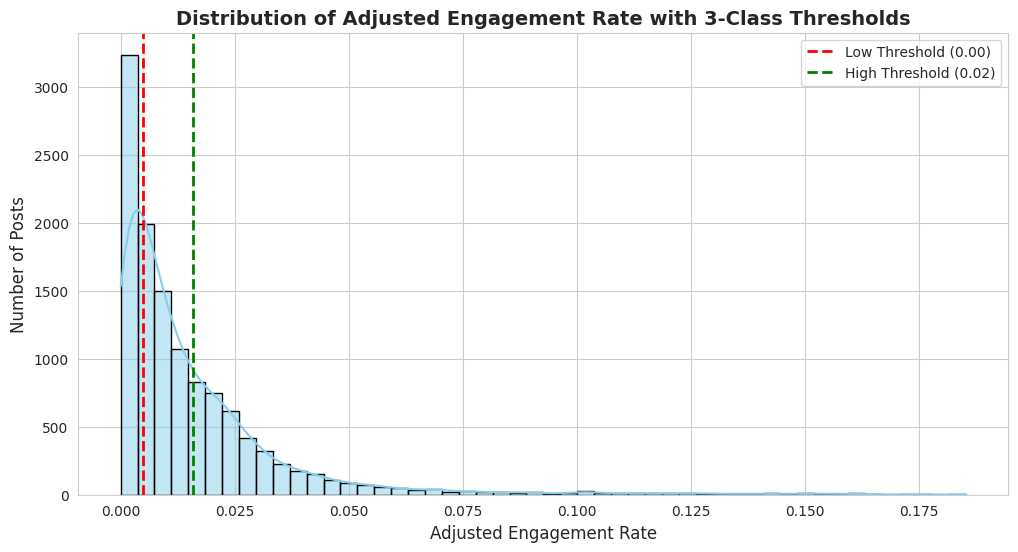


Class Distribution for Transformer Training:
engagement_class
1    33.405244
2    33.297378
0    33.297378
Name: proportion, dtype: float64


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=posts_df.copy()
target_col = 'adjusted_engagement_rate'
adjusted_engagement_rate = 'adjusted_engagement_rate'
low_threshold = df[target_col].quantile(0.333)
high_threshold = df[target_col].quantile(0.667)

print(f"--- Recommended Thresholds ---")
print(f"LOW ends at: {low_threshold:.4f}")
print(f"MEDIUM is between: {low_threshold:.4f} and {high_threshold:.4f}")
print(f"HIGH starts at: {high_threshold:.4f}\n")

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.histplot(df[target_col], bins=50, kde=True, color='skyblue', edgecolor='black')

plt.axvline(low_threshold, color='red', linestyle='dashed', linewidth=2, label=f'Low Threshold ({low_threshold:.2f})')
plt.axvline(high_threshold, color='green', linestyle='dashed', linewidth=2, label=f'High Threshold ({high_threshold:.2f})')

plt.title('Distribution of Adjusted Engagement Rate with 3-Class Thresholds', fontsize=14, fontweight='bold')
plt.xlabel('Adjusted Engagement Rate', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.legend()

# Optional: If your data is heavily skewed by viral posts, uncomment the next line to zoom in on the majority of the data
# plt.xlim(0, df[target_col].quantile(0.95))

plt.show()

def categorize_engagement(rate):
    if rate <= low_threshold:
        return 0 # Low
    elif rate <= high_threshold:
        return 1 # Medium
    else:
        return 2 # High

df['engagement_class'] = df[target_col].apply(categorize_engagement)
print("\nClass Distribution for Transformer Training:")
print(df['engagement_class'].value_counts(normalize=True) * 100)

In [9]:
# import numpy as np
# import pandas as pd

# # Optional: Keep the log transform if you still need it for your model features
# posts_df['engagement_rate_log'] = np.log1p(posts_df['adjusted_engagement_rate'])

# # 1. Calculate the true average (mean) and standard deviation
# average_rate = posts_df['adjusted_engagement_rate'].mean()
# std_dev = posts_df['adjusted_engagement_rate'].std()

# # 2. Define the boundaries for the "average" tier
# # We are using +/- 0.5 standard deviations to create a band around the mean.
# # You can change the '0.5' to a '1.0' if you want a much wider "average" bucket.
# lower_bound = average_rate - (0.5 * std_dev)
# upper_bound = average_rate + (0.5 * std_dev)

# # 3. Define the exact bin edges: negative infinity -> lower bound -> upper bound -> positive infinity
# bins = [-np.inf, lower_bound, upper_bound, np.inf]

# # 4. Use pd.cut to assign the three labels
# posts_df['engagement_label'] = pd.cut(
#     posts_df['adjusted_engagement_rate'],
#     bins=bins,
#     labels=['low', 'average', 'high']
# )

# # Print distribution and ranges
# print(f"\nOverall Average Engagement Rate: {average_rate:.4f}")
# print(f"Standard Deviation: {std_dev:.4f}")
# print(f"'Average' band: {lower_bound:.4f} to {upper_bound:.4f}")

# print(f"\nEngagement label distribution:")
# print(posts_df['engagement_label'].value_counts())

# # The observed=False parameter silences a common Pandas warning
# print("\nBin ranges:")
# print(posts_df.groupby('engagement_label', observed=False)['adjusted_engagement_rate'].agg(['min', 'max']))

In [10]:
# 4. Use pd.qcut with decimal quantiles to assign the three labels
# For a 40% low, 20% average, and 40% high split:
posts_df['engagement_label'] = pd.qcut(
    posts_df['adjusted_engagement_rate'],
    q=[0, 0.333, 0.667, 1.0],
    labels=['low', 'average', 'high']
)

# # Print distribution and ranges
# print(f"\nOverall Average Engagement Rate: {average_rate:.4f}")
# print(f"Standard Deviation: {std_dev:.4f}")
# print(f"'Average' band: {lower_bound:.4f} to {upper_bound:.4f}")

print(f"\nEngagement label distribution:")
print(posts_df['engagement_label'].value_counts())

# The observed=False parameter silences a common Pandas warning
print("\nBin ranges:")
print(posts_df.groupby('engagement_label', observed=False)['adjusted_engagement_rate'].agg(['min', 'max']))


Engagement label distribution:
engagement_label
average    4026
low        4013
high       4013
Name: count, dtype: int64

Bin ranges:
                       min       max
engagement_label                    
low               0.000000  0.004979
average           0.004985  0.015877
high              0.015880  0.185313


In [11]:
from deep_translator import GoogleTranslator
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import pandas as pd

translator = GoogleTranslator(source='auto', target='en')

def safe_translate(text):
    if pd.isna(text) or text == "":
        return text
    try:
        return translator.translate(text)
    except Exception as e:
        return text # Return original text if translation fails

# 1. Convert to a list of strings first
texts_to_translate = posts_df['post_text'].astype(str).tolist()

# 2. Use a ThreadPoolExecutor to run requests in parallel
# max_workers=20 means it will process 20 translations simultaneously
print("Starting translations...")
with ThreadPoolExecutor(max_workers=20) as executor:
    # We use tqdm to give you a live progress bar
    translated_texts = list(tqdm(executor.map(safe_translate, texts_to_translate), total=len(texts_to_translate)))

# 3. Assign the fast results back to the dataframe
posts_df['post_text_en'] = translated_texts
print("Done!")

Starting translations...


100%|██████████| 12052/12052 [02:06<00:00, 95.61it/s] 

Done!


In [12]:
# lemmatizer = WordNetLemmatizer()
# stop_words = set(stopwords.words('english'))

#TRIAL 2: EMOJI TRANSLATION
# 1. Translate Emojis to text so the model understands them
def emoji_text(text):
    if not isinstance(text, str):
        return ""
    # Convert emojis to descriptive text (e.g., 🔥 -> :fire:)
    return emoji.demojize(text)

def clean_text(text):
    # Lowercase
    text = text.lower()
    # 2. Clean colons from emojis: :fire: -> fire
    # This helps the tokenizer treat them as words rather than symbols
    text = re.sub(r':(\w+):', r' \1 ', text)

    # Remove URLs (fixed double backslash)
    text = re.sub(r"http\S+", " ", text)

    # Explicitly remove punctuation using string.punctuation (fastest method)
    # This translates all punctuation characters to None (removes them)
    # text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove any remaining non-alphanumeric characters (keep spaces)
    # text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Normalize whitespace (fixed double backslash)
    # text = re.sub(r"\s+", " ", text).strip()

    return text

def preprocess_text(text):
    emojis = emoji_text(text)
    cleaned = clean_text(emojis)
    tokens = cleaned.split()
    # # Remove stopwords
    # tokens = [t for t in tokens if t not in stop_words]
    # # Lemmatize
    # tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# 6. Apply preprocessing with progress bar
tqdm.pandas()
posts_df['post_text_clean'] = posts_df['post_text_en'].progress_apply(preprocess_text)

# Inspect original vs cleaned
print(posts_df[['post_text_en', 'post_text_clean']].head())

# 7. Save processed dataset
output_path = '/content/drive/MyDrive/gp/final_dataset_with_followers_processed.csv'
posts_df.to_csv(output_path, index=False)
print(output_path)

100%|██████████| 12052/12052 [00:04<00:00, 2496.30it/s]


                                        post_text_en  \
0  🔥The offer of 350 that breaks the world contin...   
1  The 350 offer continues until the 23rd of Rama...   
2  The 350 offer is valid until the 23rd of Ramad...   
3  Among the activities of the first day of the s...   
4  🔥 The last repetition of the 350 show that bro...   

                                     post_text_clean  
0  fire the offer of 350 that breaks the world co...  
1  the 350 offer continues until the 23rd of rama...  
2  the 350 offer is valid until the 23rd of ramad...  
3  among the activities of the first day of the s...  
4  fire the last repetition of the 350 show that ...  
/content/drive/MyDrive/gp/final_dataset_with_followers_processed.csv


In [13]:

# Make runs reproducible (reduces variance and makes tuning meaningful)

seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

os.environ["PYTHONHASHSEED"] = str(seed_val)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(seed_val)


label_encoder = LabelEncoder()
posts_df["label_id"] = label_encoder.fit_transform(posts_df["engagement_label"].astype(str))
num_labels = len(label_encoder.classes_)
print("Labels:", list(label_encoder.classes_), "num_labels:", num_labels)

# Stratified split
train_df, val_df = train_test_split(
    posts_df,
    test_size=0.1,
    random_state=seed_val,
    stratify=posts_df["label_id"]
)

print(train_df["label_id"].value_counts(normalize=True).sort_index())
print(val_df["label_id"].value_counts(normalize=True).sort_index())

print("Train size:", len(train_df), "Val size:", len(val_df))

42
Labels: ['average', 'high', 'low'] num_labels: 3
label_id
0    0.334040
1    0.332934
2    0.333026
Name: proportion, dtype: float64
label_id
0    0.334163
1    0.333333
2    0.332504
Name: proportion, dtype: float64
Train size: 10846 Val size: 1206


In [14]:
# tfidf = TfidfVectorizer(
#     max_features=20000,
#     ngram_range=(1, 2),
#     min_df=3
# )

# X_train_tfidf = tfidf.fit_transform(train_df["post_text_clean"])
# X_val_tfidf = tfidf.transform(val_df["post_text_clean"])

# log_reg = LogisticRegression(
#     max_iter=200,
#     n_jobs=-1,
#     class_weight="balanced"
# )
# log_reg.fit(X_train_tfidf, train_df["label_id"])

# val_pred_lr = log_reg.predict(X_val_tfidf)
# val_pred_lr_proba = log_reg.predict_proba(X_val_tfidf)

# tfidf_lr_qwk = cohen_kappa_score(val_df["label_id"], val_pred_lr, weights="quadratic")
# tfidf_lr_acc = accuracy_score(val_df["label_id"], val_pred_lr)
# tfidf_lr_f1 = f1_score(val_df["label_id"], val_pred_lr, average="macro")
# print("TF-IDF + LR QWK:", tfidf_lr_qwk)
# print("TF-IDF + LR accuracy:",tfidf_lr_acc)
# print("TF-IDF + LR macro F1:", tfidf_lr_f1)
# print(classification_report(val_df["label_id"], val_pred_lr, target_names=label_encoder.classes_))
# # Calculate the confusion matrix
# cm = confusion_matrix(val_df["label_id"], val_pred_lr)

# # Plot the confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=label_encoder.classes_,
#             yticklabels=label_encoder.classes_)

# plt.title('logistic+tf idf Confusion Matrix')
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.tight_layout()
# plt.show()

# # 1. Convert the confusion matrix array to a JSON string
# cm_string = json.dumps(cm.tolist())

# # 3. Log the baseline WITH the cm_data argument included!
# tracker.log_run(
#     model_name="TF-IDF + Logistic Regression",
#     accuracy=tfidf_lr_acc,
#     f1_macro=tfidf_lr_f1,
#     qwk=tfidf_lr_qwk,
#     experiment_notes="Baseline, with demoji,and log transform, max_features=20k",
#     cm_data=cm_string  # <-- This saves the matrix numbers into the CSV
# )

In [ ]:
from datasets import Dataset as HFDataset

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'qwk': cohen_kappa_score(labels, preds, weights='quadratic')
    }

def train_and_evaluate_model(model_name, train_df, val_df, num_labels, target_names, experiment_notes="",
                             learning_rate=2e-5, adam_epsilon=1e-8, warmup_ratio=0.0):
    print(f"\n{'='*50}\nTraining {model_name}\n{'='*50}")

    # 1. Initialize Tokenizer and Model
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        ignore_mismatched_sizes=True
    )

    # 2. Create HF Datasets (Fixes the AttributeError)
    def tokenize_function(examples):
        return tokenizer(examples["text"], truncation=True, padding=True, max_length=128)

    train_hf = HFDataset.from_dict({"text": train_df["post_text_clean"].tolist(), "labels": train_df["label_id"].tolist()})
    val_hf = HFDataset.from_dict({"text": val_df["post_text_clean"].tolist(), "labels": val_df["label_id"].tolist()})

    train_dataset = train_hf.map(tokenize_function, batched=True)
    val_dataset = val_hf.map(tokenize_function, batched=True)

    # 3. Define Training Arguments
    training_args = TrainingArguments(
        output_dir=f"./results_{model_name.replace('/', '_')}",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=learning_rate,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5, # Reduced for testing, set back to 50 for final
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        report_to="none",
        adam_epsilon=adam_epsilon,
        warmup_ratio=warmup_ratio,
        fp16=torch.cuda.is_available()
    )

    # 4. Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
    )

    # 5. Train and Evaluate
    trainer.train()
    eval_results = trainer.evaluate()

    # 6. Generate Predictions
    predictions = trainer.predict(val_dataset)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = val_df["label_id"].values

    acc = eval_results['eval_accuracy']
    f1 = eval_results['eval_f1_macro']
    qwk = eval_results['eval_qwk']

    print(f"\n{model_name} Results:")
    print(f"Accuracy: {acc:.4f} | Macro F1: {f1:.4f} | QWK: {qwk:.4f}")
    print(classification_report(labels, preds, target_names=target_names))

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.show()

    cm_string = json.dumps(cm.tolist())
    tracker.log_run(
        model_name=model_name,
        accuracy=acc,
        f1_macro=f1,
        qwk=qwk,
        experiment_notes=experiment_notes,
        cm_data=cm_string
    )

    return trainer, predictions.predictions
#
target_names = list(label_encoder.classes_)
experiment_notes = "with demoji,and log,3labels,preprocess different, more data 11k,weighted classes ,new formula ,new metric,new translAtion"

# # # 1. BERT
# bert_trainer, bert_probs = train_and_evaluate_model(
#     "bert-base-uncased", train_df, val_df, num_labels, target_names, experiment_notes
# )

# # FREE GPU MEMORY
# del bert_trainer
# gc.collect()
# torch.cuda.empty_cache()

# # 2. RoBERTa
roberta_trainer, roberta_probs = train_and_evaluate_model(
    "roberta-base", train_df, val_df, num_labels, target_names, experiment_notes
)

# FREE GPU MEMORY
del roberta_trainer
gc.collect()
torch.cuda.empty_cache()


# # 3. XLM-RoBERTa
xlm_trainer, xlm_probs = train_and_evaluate_model(
    "xlm-roberta-base", train_df, val_df, num_labels, target_names, experiment_notes
)

# FREE GPU MEMORY
del xlm_trainer
gc.collect()
torch.cuda.empty_cache()

# # 4. DeBERTa-v3 (Isolated Cell)

# deberta_trainer, deberta_probs = train_and_evaluate_model(
#     "microsoft/deberta-v3-base",
#     train_df,
#     val_df,
#     num_labels,
#     target_names,
#     experiment_notes=experiment_notes,
#     # OVERRIDING THE DEFAULTS:
#     learning_rate=1e-5,
#     adam_epsilon=1e-6,
#     warmup_ratio=0.1
# )

# 5. ModernBERT
modern_trainer, modern_probs = train_and_evaluate_model(
    "answerdotai/ModernBERT-base", train_df, val_df, num_labels, target_names, experiment_notes
)

del modern_trainer
gc.collect()
torch.cuda.empty_cache()

# 6. DistilBERT (ADDED)
distilbert_trainer, distilbert_probs = train_and_evaluate_model(
    "distilbert/distilbert-base-uncased", train_df, val_df, num_labels, target_names, experiment_notes
)
del distilbert_trainer
gc.collect()
torch.cuda.empty_cache()


Training roberta-base


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/10846 [00:00<?, ? examples/s]

Map:   0%|          | 0/1206 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Qwk
1,0.990691,0.876017,0.572139,0.572690,0.378375


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# =========================================================
# 1. IMPORTS & SETUP
# =========================================================
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
import gc

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# 2. CUSTOM ARCHITECTURE & LLRD
# =========================================================
class DebertaCustomClassifier(nn.Module):
    def __init__(self, model_name, num_classes=3, dropout=0.15):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.hidden_size = self.bert.config.hidden_size

        # Reordered for better stability: Linear -> GELU -> Dropout -> Norm -> Linear
        self.classifier = nn.Sequential(
            nn.Linear(self.hidden_size, self.hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.LayerNorm(self.hidden_size),
            nn.Linear(self.hidden_size, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        # Standard truncated normal initialization for Transformer heads
        for m in self.classifier:
            if isinstance(m, nn.Linear):
                torch.nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        # Mean Pooling
        last_hidden_state = outputs.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        sum_embeddings = torch.sum(last_hidden_state * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        pooled_output = sum_embeddings / sum_mask

        logits = self.classifier(pooled_output)
        return logits

def get_llrd_optimizer_params(model, encoder_lr=2e-5, decoder_lr=1e-4, weight_decay=0.01):
    no_decay = ["bias", "LayerNorm.bias", "LayerNorm.weight"]

    # Safely target the classifier head
    optimizer_parameters = [
        {'params': [p for n, p in model.classifier.named_parameters() if not any(nd in n for nd in no_decay)],
         'lr': decoder_lr, 'weight_decay': weight_decay},
        {'params': [p for n, p in model.classifier.named_parameters() if any(nd in n for nd in no_decay)],
         'lr': decoder_lr, 'weight_decay': 0.0}
    ]

    # Capture Encoder layers (DeBERTa v2/v3 architecture)
    layers = [model.bert.embeddings] + list(model.bert.encoder.layer)
    layers.reverse()
    lr = encoder_lr

    for layer in layers:
        optimizer_parameters += [
            {"params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
             "weight_decay": weight_decay, "lr": lr},
            {"params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
             "weight_decay": 0.0, "lr": lr}
        ]
        lr *= 0.95 # Gentler decay multiplier

    return optimizer_parameters

# =========================================================
# 3. DATASET CREATION
# =========================================================
def create_custom_dataset(dataframe, tokenizer, max_len=128):
    texts = dataframe['post_text_clean'].astype(str).tolist()
    labels = dataframe['label_id'].tolist()

    encodings = tokenizer(
        texts,
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='pt'
    )

    return TensorDataset(encodings['input_ids'], encodings['attention_mask'], torch.tensor(labels, dtype=torch.long))

# =========================================================
# 4. TRAINING & EVALUATION LOOP
# =========================================================
def train_and_evaluate_custom_model(model_name, train_df, val_df, num_labels, target_names,
                                    experiment_notes="", epochs=5, batch_size=16, max_len=128):

    print(f"\n{'='*50}\nTraining Custom Architecture: {model_name}\n{'='*50}")

    # Use use_fast=False for DeBERTa-v3 to avoid tokenizer bugs
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    train_dataset = create_custom_dataset(train_df, tokenizer, max_len=max_len)
    val_dataset = create_custom_dataset(val_df, tokenizer, max_len=max_len)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = DebertaCustomClassifier(model_name=model_name, num_classes=num_labels)
    model.to(DEVICE)

    # --- Handle Class Imbalance Automatically ---
    labels_array = train_df['label_id'].values
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels_array), y=labels_array)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

    # Apply weights to loss
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

    # --- Optimizer & Warmup Scheduler ---
    params = get_llrd_optimizer_params(model, encoder_lr=2e-5, decoder_lr=1e-4) # Lowered decoder_lr
    optimizer = optim.AdamW(params, eps=1e-6)

    total_steps = len(train_loader) * epochs
    warmup_steps = int(0.1 * total_steps) # 10% warmup
    scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    best_val_f1 = 0.0
    best_model_path = "best_custom_deberta.pt"

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)

        for input_ids, attention_mask, labels in train_loop:
            input_ids, attention_mask, labels = input_ids.to(DEVICE), attention_mask.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item() * input_ids.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            train_loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")

        # Validation
        model.eval()
        all_preds, all_labels = [], []
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Valid]", leave=False)

        with torch.no_grad():
            for input_ids, attention_mask, labels in val_loop:
                input_ids, attention_mask = input_ids.to(DEVICE), attention_mask.to(DEVICE)
                outputs = model(input_ids, attention_mask)
                all_preds.extend(outputs.argmax(1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(all_labels, all_preds)
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        val_qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

        print(f"Epoch {epoch+1} Completed | Train Acc: {correct/total:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | Val QWK: {val_qwk:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_model_path)
            print("  --> Best Model Saved!")

    # Final Evaluation
    print("\nLoading Best Model for Final Evaluation...")
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

    final_preds, final_probs, final_labels = [], [], []
    eval_loop = tqdm(val_loader, desc="Final Evaluation Scoring")

    with torch.no_grad():
        for input_ids, attention_mask, labels in eval_loop:
            input_ids, attention_mask = input_ids.to(DEVICE), attention_mask.to(DEVICE)
            outputs = model(input_ids, attention_mask)
            probs = torch.nn.functional.softmax(outputs, dim=-1)
            final_probs.extend(probs.cpu().numpy())
            final_preds.extend(outputs.argmax(1).cpu().numpy())
            final_labels.extend(labels.numpy())

    final_acc = accuracy_score(final_labels, final_preds)
    final_f1 = f1_score(final_labels, final_preds, average='macro')
    final_qwk = cohen_kappa_score(final_labels, final_preds, weights='quadratic')

    print(f"\n{model_name} Final Best Results:")
    print(f"Accuracy: {final_acc:.4f} | Macro F1: {final_f1:.4f} | QWK: {final_qwk:.4f}")
    print(classification_report(final_labels, final_preds, target_names=target_names))

    cm = confusion_matrix(final_labels, final_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    return model, np.array(final_probs)

    # =========================================================
# 6. EXECUTION
# =========================================================
# Ensure your target names match your 3 classes.
# (Assuming label_encoder is already in your notebook's memory)
target_names = list(label_encoder.classes_)
experiment_notes = "Custom PyTorch loop, LLRD, Warmup, Class Weights, DeBERTa-v3"
num_labels = len(target_names)

# Run the pipeline
custom_model, custom_probs = train_and_evaluate_custom_model(
    model_name="microsoft/deberta-v3-base",
    train_df=train_df,
    val_df=val_df,
    num_labels=num_labels,
    target_names=target_names,
    experiment_notes=experiment_notes,
    epochs=5,          # Keep at 5 to test if it learns, then increase if needed
    batch_size=16,     # Lower to 8 if you get a CUDA Out of Memory error
    max_len=128
)

# Clean up GPU memory so you can run other cells without crashing
del custom_model
gc.collect()
torch.cuda.empty_cache()

print("Training complete and GPU memory cleared!")